## Sélection du corpus de travail

123 181 avis

**Sélection de 2 000 avis** selon : **suffisamment proches du corpus réel, tout en étant suffisamment riches pour apprendre les aspects et le sentiment.** **pas forcement une représentativité parfaite**


**constituer un sous-corpus suffisamment représentatif de sa diversité tout en garantissant une couverture suffisante des phénomènes linguistiques nécessaires à la détection des aspects et à l’analyse de sentiment.**
- la répartition des `stars`
- les `category`
- la diversité des entreprises
- la longueur des avis

**Sur ces 2 000 avis :**

calcul de la **richesse lexicale**
**Contrôle :**
Vérifier si l’échantillon contient suffisamment d’avis avec :
- des signaux liés aux **aspects**
- des signaux liés au **sentiment**
- des expressions pertinentes
- des avis potentiellement multi-aspects

**Sélection de 600 avis pilotes** en tenant compte de cette richesse lexicale, tout en conservant une diversité d’avis.

In [2]:
import pandas as pd
#!conda install -c conda-forge scikit-learn -y
from sklearn.model_selection import train_test_split

In [3]:
# corpus 2000avis d'annotations
df_nlp = pd.read_csv("../data/df_nlp.csv")
df_nlp.head()

,company,category,title,review,stars,texte_complet,longueur_review
0,ruffandtumbledogcoats.com,Animals & Pets,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5,Great quality dog drying robe although… Great ...,89
1,ruffandtumbledogcoats.com,Animals & Pets,Really prompt service,"Really prompt service, The sofa covers have no...",5,"Really prompt service Really prompt service, T...",202
2,ruffandtumbledogcoats.com,Animals & Pets,Life saver,I’ve purchased first of those coats in May2020...,5,Life saver I’ve purchased first of those coats...,469
3,ruffandtumbledogcoats.com,Animals & Pets,Brilliant coats,Brilliant coats. Really like the limited editi...,5,Brilliant coats Brilliant coats. Really like t...,260
4,ruffandtumbledogcoats.com,Animals & Pets,Great company and products,Great company and products. This is my 3rd dry...,5,Great company and products Great company and p...,157


## Ajout d'un review_id

In [4]:
# Réinitialisation de l'index du DataFrame
# drop=True : supprime l'ancien index au lieu de l'ajouter
#             comme nouvelle colonne dans le DataFrame
# L'index devient donc une séquence 0, 1, 2, ..., n-1
df_nlp = df_nlp.reset_index(drop=True)

# Création d'une colonne "review_id"
# On utilise l'index (qui vient d'être réinitialisé) comme
# identifiant unique de chaque avis (review).
# Cela garantit un ID unique et séquentiel pour chaque ligne.
df_nlp["review_id"] = df_nlp.index

# Aperçu des 5 premières lignes du DataFrame
df_nlp.head()

,company,category,title,review,stars,texte_complet,longueur_review,review_id
0,ruffandtumbledogcoats.com,Animals & Pets,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5,Great quality dog drying robe although… Great ...,89,0
1,ruffandtumbledogcoats.com,Animals & Pets,Really prompt service,"Really prompt service, The sofa covers have no...",5,"Really prompt service Really prompt service, T...",202,1
2,ruffandtumbledogcoats.com,Animals & Pets,Life saver,I’ve purchased first of those coats in May2020...,5,Life saver I’ve purchased first of those coats...,469,2
3,ruffandtumbledogcoats.com,Animals & Pets,Brilliant coats,Brilliant coats. Really like the limited editi...,5,Brilliant coats Brilliant coats. Really like t...,260,3
4,ruffandtumbledogcoats.com,Animals & Pets,Great company and products,Great company and products. This is my 3rd dry...,5,Great company and products Great company and p...,157,4


## garder la diversité sur les 2000 avis
étoiles + catégories

In [5]:
# Création d'une colonne "strate" (variable de stratification) // conversion en texte
df_nlp["strate"] = (df_nlp["category"].astype(str) + "_" + df_nlp["stars"].astype(str))

# Comptage des occurrences de chaque strate
df_nlp["strate"].value_counts()

strate
Business Services_5              1719
Sports_5                         1705
Restaurants & Bars_5             1704
Education & Training_5           1702
Hobbies & Crafts_5               1655
                                 ... 
Restaurants & Bars_2              778
Beauty & Well-being_2             769
Legal Services & Government_2     724
Hobbies & Crafts_2                700
Public & Local Services_2         689
Name: count, Length: 110, dtype: int64

## Sélection de 2 000 avis

In [6]:
# Split stratifié(préserve la proportion) : extraction d'un échantillon de 2000 lignes
df_2000, df_reste = train_test_split(df_nlp, train_size=2000, random_state=42, 
                                     stratify=df_nlp["strate"])
display(df_2000.shape)
df_2000.head()

(2000, 9)

,company,category,title,review,stars,texte_complet,longueur_review,review_id,strate
113247,otta.com,Public & Local Services,Awesome product,"Awesome product. Very mobile friendly, functio...",5,Awesome product Awesome product. Very mobile f...,248,113247,Public & Local Services_5
50548,wagamama.co.uk,Restaurants & Bars,"Good food, slow service.","Four of us, 3 adults and 1 2 year old went for...",3,"Good food, slow service. Four of us, 3 adults ...",496,50548,Restaurants & Bars_3
67572,safetygloves.co.uk,Construction & Manufacturing,Good gloves and service,I ordered the hex armour thorn armour 3092 in ...,5,Good gloves and service I ordered the hex armo...,553,67572,Construction & Manufacturing_5
70820,pozitive.energy,Utilities,Dec 24 I spoke with Sneha Vasani this…,I spoke with Sneha Vasani this afternoon who w...,4,Dec 24 I spoke with Sneha Vasani this… I spoke...,337,70820,Utilities_4
17006,achamilton.co.uk,Hobbies & Crafts,Polite and knowledgeable individual…,Polite and knowledgeable individual dealt with...,4,Polite and knowledgeable individual… Polite an...,145,17006,Hobbies & Crafts_4


In [7]:
# Suppression de la colonne "strate" dans df_2000
df_2000 = df_2000.drop("strate", axis=1)
df_2000.head()

,company,category,title,review,stars,texte_complet,longueur_review,review_id
113247,otta.com,Public & Local Services,Awesome product,"Awesome product. Very mobile friendly, functio...",5,Awesome product Awesome product. Very mobile f...,248,113247
50548,wagamama.co.uk,Restaurants & Bars,"Good food, slow service.","Four of us, 3 adults and 1 2 year old went for...",3,"Good food, slow service. Four of us, 3 adults ...",496,50548
67572,safetygloves.co.uk,Construction & Manufacturing,Good gloves and service,I ordered the hex armour thorn armour 3092 in ...,5,Good gloves and service I ordered the hex armo...,553,67572
70820,pozitive.energy,Utilities,Dec 24 I spoke with Sneha Vasani this…,I spoke with Sneha Vasani this afternoon who w...,4,Dec 24 I spoke with Sneha Vasani this… I spoke...,337,70820
17006,achamilton.co.uk,Hobbies & Crafts,Polite and knowledgeable individual…,Polite and knowledgeable individual dealt with...,4,Polite and knowledgeable individual… Polite an...,145,17006


In [8]:
# Affichage du nombre d'avis dans df_2000 - shape[0] : nombre de LIGNES (= nombre d'avis) 
print("Nombre d'avis :", df_2000.shape[0])

Nombre d'avis : 2000


In [9]:
# Distribution des notes (stars) dans df_2000 // compte occurrences.retrie par index
print(df_2000["stars"].value_counts().sort_index())

stars
1    392
2    317
3    346
4    423
5    522
Name: count, dtype: int64


In [10]:
# Affichage du nombre de catégories uniques dans df_2000 // nbr val unique
print("Nombre de catégories :", df_2000["category"].nunique())

Nombre de catégories : 22


In [11]:
# Affichage du nombre d'entreprises uniques dans df_2000
print("Nombre d'entreprises :", df_2000["company"].nunique())

Nombre d'entreprises : 1105


In [12]:
# Statistiques descriptives de la longueur des avis
df_2000["longueur_review"].describe()

count    2000.000000
mean      353.199000
std       302.223194
min        14.000000
25%       179.000000
50%       281.000000
75%       434.000000
max      3995.000000
Name: longueur_review, dtype: float64

## Analyse de representativité

corpus final qui servira ensuite à l’annotation puis au ML.Donc on veut qu’il reste aussi proche que possible de la diversité réelle du corpus : avis courts, longs, riches, pauvres, explicites, implicites, avec ou sans mots-clés connus.
Afin de constituer le corpus destiné à l'annotation, un échantillon de
2 000 avis est extrait du corpus NLP. La sélection est stratifiée selon
la catégorie et la note afin de conserver la diversité du corpus initial.

### 2. Analyse de la richesse lexicale

L'objectif est d'évaluer, parmi les 2 000 avis sélectionnés, la présence de termes pouvant fournir des signaux sur les aspects métier et le sentiment.

Cette analyse reprend les listes de mots et d'expressions utilisées lors de l'analyse exploratoire du Rendu 1.

La richesse lexicale n'est pas utilisée comme un label. Elle sert uniquement à identifier les avis contenant davantage de signaux potentiellement utiles pour la constitution du corpus pilote.

In [13]:
# Création de la colonne "texte_minuscule" (normalisation casse) // conv.chaine.miniscule
df_2000["texte_minuscule"] = df_2000["texte_complet"].astype(str).str.lower()

**2.1 Termes liés aux aspects**

In [14]:
# liste de termes liés à différents aspects
mots_aspects = ["service", "support", "customer", "staff",
                "delivery", "shipping", "order", "arrived",
                "product", "quality", "item", "broken", "damaged",
                "price", "cost", "purchase",
                "refund", "return", "replacement",
                "website", "app", "payment"]

In [15]:
# Comptage du nombre de signaux d'aspects distincts par avis
df_2000["nb_signaux_aspects"] = 0

for mot in mots_aspects:
                                                # "\\b" + mot + "\\b" :regex avec limites de mots, évite les faux positifs ("app" ne matche plus "happy")
    presence = df_2000["texte_minuscule"].str.contains(r"\b" + mot + r"\b", regex=True)
    
    df_2000["nb_signaux_aspects"] = (df_2000["nb_signaux_aspects"] + presence.astype(int))

**2.2 Termes liés au sentiment**

In [16]:
# liste de termes liés à différents sentiment
mots_sentiment = ["good", "great", "excellent",
                  "helpful", "easy", "fast",
                  "bad", "poor", "terrible", "slow", "late",
                  "problem", "issue", "disappointed"]

In [17]:
# Comptage du nombre de signaux de sentiment par avis
df_2000["nb_signaux_sentiment"] = 0

for mot in mots_sentiment:
    
    presence = df_2000["texte_minuscule"].str.contains(r"\b" + mot + r"\b", regex=True)
    
    df_2000["nb_signaux_sentiment"] = (df_2000["nb_signaux_sentiment"] + presence.astype(int))

**2.3 Expressions et négations**

In [18]:
# Définition d'un lexique d'expressions negatives (négations)
expressions_negatives = ["not good", "not great", "not helpful",
                         "not easy", "not fast",
                         "wasn't good", "wasn't great",
                         "isn't good", "isn't great"]

In [19]:
# Définition d'un lexique d'esxpressions multi-mot
expressions = ["customer service", "fast delivery", "late delivery", "slow delivery",
               "poor service", "good quality", "refund process"]

In [20]:
# Comptage du nombre de négations par avis
df_2000["nb_negations"] = 0

for expression in expressions_negatives:
    presence = df_2000["texte_minuscule"].str.contains(expression,regex=False)
    df_2000["nb_negations"] = (df_2000["nb_negations"] + presence.astype(int))

In [21]:
# Comptage du nombre d'expressions multi-mots par avis
df_2000["nb_expressions"] = 0

for expression in expressions:
    presence = df_2000["texte_minuscule"].str.contains( expression, regex=False)
    df_2000["nb_expressions"] = (df_2000["nb_expressions"] + presence.astype(int))

**2.4 Construire le score de richesse**

In [22]:
# Calcul d'un score de richesse global par avis
df_2000["score_richesse"] = (df_2000["nb_signaux_aspects"]+ df_2000["nb_signaux_sentiment"]
                             + df_2000["nb_negations"] + df_2000["nb_expressions"])

#   score_richesse = nb_signaux_aspects + nb_signaux_sentiment
#                  + nb_negations + nb_expressions

In [23]:
# Statistiques descriptives du score de richesse
df_2000["score_richesse"].describe()

count    2000.000000
mean        2.448000
std         2.070372
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        13.000000
Name: score_richesse, dtype: float64

In [24]:
# Distribution complète des valeurs du score de richesse
df_2000["score_richesse"].value_counts().sort_index()

score_richesse
0     329
1     464
2     388
3     287
4     221
5     138
6      84
7      42
8      22
9      14
10      5
11      3
12      1
13      2
Name: count, dtype: int64

In [25]:
# Inspection des 20 avis les plus riches
df_2000[["review_id", "texte_complet", "stars", "nb_signaux_aspects", "nb_signaux_sentiment",
         "nb_negations", "nb_expressions","score_richesse"]].sort_values("score_richesse",ascending=False).head(20)

# Segmentation en 3 niveaux de richesse ]-1, 1] ]1, 3] ]3, 13]
df_2000["niveau_richesse"] = pd.cut(df_2000["score_richesse"], bins=[-1, 1, 3, 13],
                                    labels=["Faible", "Moyenne", "Forte"])
repartition = df_2000["niveau_richesse"].value_counts()
pourcentage = df_2000["niveau_richesse"].value_counts(normalize=True) * 100
tableau_richesse = pd.DataFrame({"Nombre_avis": repartition, "Pourcentage": pourcentage.round(1)})
display(tableau_richesse)

,Nombre_avis,Pourcentage
niveau_richesse,,
Faible,793,39.6
Moyenne,675,33.8
Forte,532,26.6


In [26]:
# Statistiques de longueur par niveau de richesse // corrélé a longeur des avis ?
df_2000.groupby("niveau_richesse")["longueur_review"].describe()

,count,mean,std,min,25%,50%,75%,max
niveau_richesse,,,,,,,,
Faible,793.0,276.833544,197.322469,14.0,145.00,237.0,359.0,1983.0
Moyenne,675.0,344.718519,260.072264,26.0,188.50,281.0,426.0,2896.0
Forte,532.0,477.789474,419.016022,34.0,235.75,377.0,569.5,3995.0


In [27]:
# Corrélation entre longueur de l'avis et score de richesse
df_2000[["longueur_review", "score_richesse"]].corr()
# -> liaison modérée, info complémentaire

,longueur_review,score_richesse
longueur_review,1.000000,0.363296
score_richesse,0.363296,1.000000


In [28]:
# Tableau croisé : niveau de richesse × note (stars)
pd.crosstab(df_2000["niveau_richesse"], df_2000["stars"], normalize="index").round(3)
# relation entre le niveau de richesse d'un avis et la NOTE attribuée

stars,1,2,3,4,5
niveau_richesse,,,,,
Faible,0.209,0.172,0.178,0.221,0.221
Moyenne,0.187,0.138,0.166,0.213,0.296
Forte,0.188,0.165,0.175,0.195,0.276


## 3. Validation de la représentativité de l'échantillon de 2 000 avis

L'objectif n'est pas de reproduire exactement le corpus complet de 123 181 avis, mais de vérifier que l'échantillon de 2 000 avis conserve une diversité suffisante et ne présente pas de déséquilibre majeur.

La comparaison porte dans un premier temps sur :
- la répartition des étoiles ;
- la répartition des catégories ;
- la diversité des entreprises ;
- la longueur des avis.

Une comparaison lexicale sera ensuite réalisée afin de vérifier que le vocabulaire de l'échantillon reste cohérent avec celui du corpus complet.

1. Comparaison des étoiles

In [29]:
# Comparaison de la distribution des notes : corpus vs échantillon
# value_counts(normalize=True)..sort_index()
# proportions (0 à 1).tri par note croissante (1→5).conversion en pourcentage
# Distribution des notes dans le corpus complet (df_nlp)
stars_global = df_nlp["stars"].value_counts(normalize=True).sort_index() * 100
# Distribution des notes dans l'échantillon (df_2000)
stars_2000 = df_2000["stars"].value_counts(normalize=True).sort_index() * 100

# Const. du tableau comparatif
comparaison_stars = pd.DataFrame({"Corpus_123k": stars_global.round(2),"Echantillon_2000": stars_2000.round(2)})
# Calcul de l'écart (échantillon - corpus)
comparaison_stars["Ecart"] = (comparaison_stars["Echantillon_2000"] - comparaison_stars["Corpus_123k"]).round(2)
display(comparaison_stars)

,Corpus_123k,Echantillon_2000,Ecart
stars,,,
1,19.54,19.60,0.06
2,15.98,15.85,-0.13
3,17.26,17.30,0.04
4,21.12,21.15,0.03
5,26.10,26.10,0.00


In [30]:
# Comparaison de la distribution des CATÉGORIES : corpus vs échantillon
# Distribution des catégories dans le corpus complet
categories_global = df_nlp["category"].value_counts(normalize=True) * 100

# Distribution des catégories dans l'échantillon
categories_2000 = df_2000["category"].value_counts(normalize=True) * 100

# Const du tableau comparatif // aligne les deux Series sur leur INDEX
comparaison_categories = pd.DataFrame({"Corpus_123k": categories_global,"Echantillon_2000": categories_2000})

# Calcul de l'écart (échantillon - corpus)
comparaison_categories["Ecart"] = (comparaison_categories["Echantillon_2000"] - 
                                   comparaison_categories["Corpus_123k"])
comparaison_categories = comparaison_categories.round(2)

display(comparaison_categories)


#comparaison_categories["Ecart_absolu"] = comparaison_categories["Ecart"].abs()
#comparaison_categories.sort_values("Ecart_absolu", ascending=False).head(10)

,Corpus_123k,Echantillon_2000,Ecart
category,,,
Animals & Pets,4.42,4.40,-0.02
Beauty & Well-being,4.22,4.20,-0.02
Business Services,5.03,5.00,-0.03
Construction & Manufacturing,4.33,4.30,-0.03
Education & Training,5.17,5.20,0.03
Electronics & Technology,4.54,4.55,0.01
Events & Entertainment,4.30,4.25,-0.05
"Food, Beverages & Tobacco",4.79,4.80,0.01
Health & Medical,4.58,4.60,0.02


3. Diversité des entreprises

In [31]:
# Nombre d'entreprises uniques dans le corpus complet
nb_entreprises_global = df_nlp["company"].nunique()
# Nombre d'entreprises uniques dans l'échantillon
nb_entreprises_2000 = df_2000["company"].nunique()

print("Entreprises dans le corpus global :", nb_entreprises_global)
print("Entreprises dans les 2 000 avis :", nb_entreprises_2000)

Entreprises dans le corpus global : 1680
Entreprises dans les 2 000 avis : 1105


In [32]:
# Calcul et affichage du taux de couverture des entreprises
couverture_entreprises = (nb_entreprises_2000 / nb_entreprises_global) * 100
print("Couverture des entreprises :", round(couverture_entreprises, 1),"%")

Couverture des entreprises : 65.8 %


In [33]:
df_2000["company"].value_counts().head(10)

company
conceptoclinic.co.uk          8
savecobradford.co.uk          7
www.zenco.com                 6
workwellsolutions.com         6
freesnaps.co.uk               6
thecornishfishmonger.co.uk    6
www.atheneum.ai               6
www.cartridgesave.co.uk       5
funkincocktails.co.uk         5
www.creation.co.uk            5
Name: count, dtype: int64

4. Comparaison des longueurs

In [34]:
# Comparaison de la longueur des avis : corpus vs échantillon
comparaison_longueur = pd.DataFrame({"Corpus_123k": df_nlp["longueur_review"].describe(),
                                     "Echantillon_2000": df_2000["longueur_review"].describe()})
display(comparaison_longueur.round(2))

,Corpus_123k,Echantillon_2000
count,123181.00,2000.00
mean,358.79,353.20
std,314.55,302.22
min,10.00,14.00
25%,177.00,179.00
50%,290.00,281.00
75%,440.00,434.00
max,9956.00,3995.00


### Conclusion sur la représentativité structurelle

La comparaison entre le corpus complet de 123 181 avis et l'échantillon de
2 000 avis montre une très forte proximité concernant la répartition des
étoiles et des catégories.

La diversité des entreprises est également importante : 1 105 entreprises
différentes sont représentées dans l'échantillon, soit 65,8 % des entreprises
du corpus complet, sans concentration importante sur une entreprise particulière.

Les distributions de longueur des avis sont également proches, notamment
pour la moyenne, la médiane et les quartiles.

Ces résultats indiquent que l'échantillon de 2 000 avis conserve correctement
la diversité structurelle du corpus initial.

La représentativité lexicale doit cependant encore être vérifiée avant de
valider définitivement cet échantillon pour la suite du projet.

4. Comparaison du profil lexical

### Comparaison du profil lexical du corpus global et de l'échantillon

Après avoir vérifié la proximité structurelle entre le corpus complet et
l'échantillon de 2 000 avis, une comparaison lexicale est réalisée.

L'objectif est de vérifier que les termes les plus présents dans le corpus
complet restent également représentés dans l'échantillon de 2 000 avis.

Les fréquences sont comparées sous forme de proportions afin de tenir compte
de la différence importante de taille entre les deux corpus.

4.1. Nettoyage du corpus global

In [35]:
df_mots_global = df_nlp[["texte_complet"]].copy()

# tout en chaîne, tout en minuscules, remplace tout caractère qui n'est PAS une lettre minuscule a-z, 
# un espace (\s), une apostrophe (') par un espace
df_mots_global["texte_nettoye"] = (df_mots_global["texte_complet"].astype(str).str.lower()
    .str.replace(r"[^a-z\s']", " ", regex=True))

# Extraction de TOUS les mots du corpus (liste à plat); .str.split() découpe chaque texte sur les espaces
# .explode() transforme chaque élément de liste en ligne distincte : une ligne = UN MOT
mots_global = df_mots_global["texte_nettoye"].str.split().explode()

4.2. Même traitement sur les 2 000

In [36]:
df_mots_2000 = df_2000[["texte_complet"]].copy()

# tout en chaîne, tout en minuscules, remplace tout caractère qui n'est PAS une lettre minuscule a-z, 
# un espace (\s), une apostrophe (') par un espace
df_mots_2000["texte_nettoye"] = (df_mots_2000["texte_complet"].astype(str).str.lower()
    .str.replace(r"[^a-z\s']", " ", regex=True))

# Extraction de TOUS les mots du corpus (liste à plat); .str.split() découpe chaque texte sur les espaces
# .explode() transforme chaque élément de liste en ligne distincte : une ligne = UN MOT
mots_2000 = df_mots_2000["texte_nettoye"].str.split().explode()

4.3. Retirer les mêmes mots très fréquents

In [37]:
# Définition d'une liste de mots à retirer (stopwords)
mots_a_retirer = ["the", "a", "an", "and", "or", "but", "of", "to", "in", "on", "for",
                  "is", "it", "this", "that", "was", "were", "are", "be", "been", "with",
                  "my", "i", "you", "they", "we", "he", "she", "as", "at", "from", "by"]

# ~mots_global.isin(mots_a_retirer): True pour les mots QUI NE SONT PAS des stopwords; ~ NOT IN
# mots_global.str.len() > 2 : True pour les mots de 3 caractères ou plus; 
# élimine les mots très courts (souvent peu informatifs)
mots_utiles_global = mots_global[(~mots_global.isin(mots_a_retirer)) & (mots_global.str.len() > 2)]

mots_utiles_2000 = mots_2000[(~mots_2000.isin(mots_a_retirer)) & (mots_2000.str.len() > 2)]

4.4. Comparer les 20 mots dominants

In [38]:
# Top 20 des mots les plus fréquents et utiles dans le corpus global
top20_global = mots_utiles_global.value_counts().head(20)

display(top20_global)

texte_nettoye
not         73753
have        71092
very        51238
had         51173
service     45571
good        34271
would       33978
time        31179
delivery    30718
all         30560
them        28863
when        28842
great       28827
which       25002
order       24194
out         23084
customer    22912
get         22287
company     22269
will        21754
Name: count, dtype: int64

In [39]:
# Fréquences relatives des mots (proportions en %)
frequence_global = mots_utiles_global.value_counts(normalize=True) * 100
frequence_2000 = mots_utiles_2000.value_counts(normalize=True) * 100

comparaison_lexicale = pd.DataFrame({"Corpus_123k": frequence_global[top20_global.index],
                                     "Echantillon_2000": frequence_2000.reindex(top20_global.index)})

comparaison_lexicale["Ecart"] = (comparaison_lexicale["Echantillon_2000"]
                                 - comparaison_lexicale["Corpus_123k"])

comparaison_lexicale = comparaison_lexicale.round(3)

display(comparaison_lexicale)

,Corpus_123k,Echantillon_2000,Ecart
texte_nettoye,,,
not,1.379,1.358,-0.021
have,1.329,1.290,-0.039
very,0.958,0.947,-0.011
had,0.957,0.932,-0.025
service,0.852,0.849,-0.003
good,0.641,0.687,0.046
would,0.635,0.568,-0.068
time,0.583,0.577,-0.006
delivery,0.574,0.547,-0.028


In [40]:
top20_2000 = mots_utiles_2000.value_counts().head(20)
display(top20_2000)

texte_nettoye
not         1167
have        1109
very         814
had          801
service      730
good         590
time         496
would        488
delivery     470
great        469
all          465
them         459
when         459
order        421
which        411
customer     391
out          360
will         353
get          350
one          348
Name: count, dtype: int64

In [41]:
# Intersection des Top 20 : corpus vs échantillon
mots_communs = set(top20_global.index) & set(top20_2000.index)

print("Nombre de mots communs dans les deux Top 20 :", len(mots_communs))
print(mots_communs)

Nombre de mots communs dans les deux Top 20 : 19
{'customer', 'all', 'them', 'delivery', 'very', 'not', 'time', 'will', 'good', 'service', 'have', 'get', 'order', 'had', 'would', 'out', 'great', 'which', 'when'}


### Conclusion sur la représentativité lexicale

La comparaison du vocabulaire entre le corpus complet et l'échantillon de
2 000 avis montre une forte proximité lexicale.

Parmi les 20 mots les plus fréquents du corpus complet, 19 apparaissent
également dans les 20 mots les plus fréquents de l'échantillon, soit
95 % de mots communs.

Les fréquences relatives des principaux termes sont également très proches
entre les deux corpus, notamment pour des termes directement liés au sujet
comme `service`, `delivery`, `good`, `great`, `order` et `customer`.

Ces résultats, associés aux comparaisons précédentes sur les étoiles,
les catégories, les entreprises et la longueur des avis, permettent de
considérer l'échantillon de 2 000 avis comme suffisamment représentatif
du corpus initial pour la suite du projet.

#### Couverture des termes dans les 2 000 avis

En complément du score de richesse, la présence de chaque terme est mesurée
au niveau des avis. Pour chaque terme, on calcule le nombre et le pourcentage
d'avis de l'échantillon dans lesquels il apparaît au moins une fois.

Cette mesure permet de distinguer la fréquence brute d'un mot de sa couverture
réelle dans le corpus.

**Aspects**

In [42]:
# Analyse de la couverture des mots d'aspects dans df_2000

# Liste accumulatrice : recevra une ligne [mot, nb_avis, %] par mot
couverture_aspects = []

for mot in mots_aspects:
# Détection du mot dans tous les avis (vectorisé)
# - r"\b" + mot + r"\b" : word boundary → évite les faux positifs ("app" ne matche pas "happy")
    #- regex=True : traite le motif comme une regex
    # - .str.contains() : renvoie une Series de booléens
    presence = df_2000["texte_minuscule"].str.contains(r"\b" + mot + r"\b", regex=True)
    nb_avis = presence.sum()
    pourcentage = presence.mean() * 100
    couverture_aspects.append([mot, nb_avis, round(pourcentage, 1)])

tableau_aspects_2000 = pd.DataFrame(couverture_aspects, 
                                    columns=["Terme", "Nombre_avis", "Pourcentage_avis"])

tableau_aspects_2000 = tableau_aspects_2000.sort_values("Nombre_avis", ascending=False)

display(tableau_aspects_2000)

,Terme,Nombre_avis,Pourcentage_avis
0,service,491,24.6
4,delivery,310,15.5
2,customer,275,13.8
6,order,252,12.6
7,arrived,178,8.9
9,quality,145,7.2
13,price,132,6.6
19,website,121,6.0
16,refund,119,5.9
3,staff,118,5.9


**Sentiments**

In [43]:
# Analyse de la couverture des mots de sentiment dans df_2000

couverture_sentiment = []

for mot in mots_sentiment:
    
    presence = df_2000["texte_minuscule"].str.contains(r"\b" + mot + r"\b",regex=True)
    nb_avis = presence.sum()
    pourcentage = presence.mean() * 100
    couverture_sentiment.append([mot, nb_avis, round(pourcentage, 1)])

tableau_sentiment_2000 = pd.DataFrame(couverture_sentiment,
                                      columns=["Terme", "Nombre_avis", "Pourcentage_avis"])

tableau_sentiment_2000 = tableau_sentiment_2000.sort_values("Nombre_avis", ascending=False)

display(tableau_sentiment_2000)

,Terme,Nombre_avis,Pourcentage_avis
0,good,404,20.2
1,great,331,16.6
3,helpful,159,8.0
4,easy,152,7.6
2,excellent,136,6.8
7,poor,104,5.2
11,problem,95,4.8
12,issue,87,4.4
13,disappointed,80,4.0
5,fast,58,2.9


### Conclusion

L'analyse montre que l'échantillon de 2 000 avis conserve une structure et un
profil lexical proches de ceux du corpus complet.

L'analyse des termes liés aux aspects et au sentiment permet également de
vérifier leur présence et leur niveau de couverture dans l'échantillon.

L'objectif n'est pas de sélectionner uniquement les avis contenant des termes
facilement identifiables, mais de conserver une configuration proche de celle
du corpus global : avis avec ou sans termes connus, formulations variées,
cas ambigus et expressions plus ou moins explicites.

Cette diversité est importante pour la suite du projet, notamment pour la
construction de l'ontologie et l'apprentissage des différents modèles de
Machine Learning et de Deep Learning.

**Resumé premeiere partie**
1. Sélection des 2 000 avis
2. Validation structurelle
   - étoiles
   - catégories
   - entreprises
   - longueurs

3. Validation lexicale
   - Top 20 du corpus 123k vs 2 000
   - 19/20 mots communs

4. Analyse exploratoire de la richesse
   - nb_signaux_aspects
   - nb_signaux_sentiment
   - score_richesse V1
   - niveaux Faible / Moyenne / Forte
   - relation avec longueur et étoiles

5. Couverture des termes dans les 2 000 avis
   - aspects
   - sentiment

6. Constitution du corpus pilote de 600 avis

## 6. Constitution du corpus pilote de 600 avis

Un sous-corpus pilote de 600 avis est extrait des 2 000 avis afin de construire
et stabiliser l'ontologie des aspects avant l'annotation complète.

La sélection est stratifiée selon la catégorie et le nombre d'étoiles afin
de conserver la structure générale de l'échantillon de 2 000 avis.

Le score de richesse lexicale n'est pas utilisé comme critère de sélection.
Il sera uniquement contrôlé après l'échantillonnage afin de vérifier que les
avis simples, riches, ambigus ou ne contenant aucun terme du lexique restent
naturellement représentés.


Crée temporairement une strate

In [44]:
df_2000["strate_pilote"] = (df_2000["category"].astype(str) + "_" + df_2000["stars"].astype(str))

Selecionner les 600 avis pilots avec train_test_split

In [45]:
df_pilote_600, df_reste_1400 = train_test_split(df_2000, train_size=600, random_state=42,
                                                stratify=df_2000["strate_pilote"])

Retirer la colonne temporaire et virfier la selection

In [46]:
df_pilote_600 = df_pilote_600.drop(columns=["strate_pilote"])

df_reste_1400 = df_reste_1400.drop(columns=["strate_pilote"])

df_2000 = df_2000.drop(columns=["strate_pilote"])

print("Nombre d'avis pilotes :", len(df_pilote_600))
print("Nombre d'avis restants :", len(df_reste_1400))

Nombre d'avis pilotes : 600
Nombre d'avis restants : 1400


Controle des etoiles sur les 600 avis

In [47]:
stars_2000 = df_2000["stars"].value_counts(normalize=True).sort_index() * 100
stars_600 = df_pilote_600["stars"].value_counts(normalize=True).sort_index() * 100

comparaison_stars_600 = pd.DataFrame({"Echantillon_2000": stars_2000,"Pilote_600": stars_600})

comparaison_stars_600["Ecart"] = (comparaison_stars_600["Pilote_600"] 
                                  - comparaison_stars_600["Echantillon_2000"])

display(comparaison_stars_600.round(2))

,Echantillon_2000,Pilote_600,Ecart
stars,,,
1,19.60,19.50,-0.10
2,15.85,16.00,0.15
3,17.30,17.00,-0.30
4,21.15,21.33,0.18
5,26.10,26.17,0.07


Controle du niveau de richesse

In [50]:
richesse_2000 = (df_2000["niveau_richesse"].value_counts(normalize=True).sort_index()* 100)

richesse_600 = (df_pilote_600["niveau_richesse"].value_counts(normalize=True).sort_index()* 100)

comparaison_richesse_600 = pd.DataFrame({"Echantillon_2000": richesse_2000,"Pilote_600": richesse_600})

comparaison_richesse_600["Ecart"] = (comparaison_richesse_600["Pilote_600"]
                                     - comparaison_richesse_600["Echantillon_2000"])

display(comparaison_richesse_600.round(1))

,Echantillon_2000,Pilote_600,Ecart
niveau_richesse,,,
Faible,39.6,40.5,0.9
Moyenne,33.8,33.3,-0.4
Forte,26.6,26.2,-0.4


Controle pourcentage score_richesse 0

In [51]:
nb_score_zero = (df_pilote_600["score_richesse"] == 0).sum()

pourcentage_score_zero = (nb_score_zero / len(df_pilote_600) * 100)

print("Avis avec score_richesse = 0 :", nb_score_zero)
print("Pourcentage :", round(pourcentage_score_zero, 1), "%")

Avis avec score_richesse = 0 : 100
Pourcentage : 16.7 %


Controle de longeur d'avis

In [52]:
comparaison_longueur_600 = pd.DataFrame({"Echantillon_2000": df_2000["longueur_review"].describe(),
                                         "Pilote_600": df_pilote_600["longueur_review"].describe()})

display(comparaison_longueur_600.round(2))

,Echantillon_2000,Pilote_600
count,2000.00,600.00
mean,353.20,353.15
std,302.22,304.44
min,14.00,22.00
25%,179.00,168.75
50%,281.00,285.00
75%,434.00,424.25
max,3995.00,3163.00


**Les résultats sont bons :**

- Étoiles : écart maximal de seulement 0,30 point.
- Richesse : distributions quasiment identiques (+0,9, -0,4, -0,4).
- Score_richesse = 0 : 16,7 % dans les 600 contre 16,45 % environ dans les 2 000. Donc les avis hors lexique ont bien été conservés naturellement.
- Longueur : moyenne quasiment identique (353,15 vs 353,20) et médiane très proche (285 vs 281).


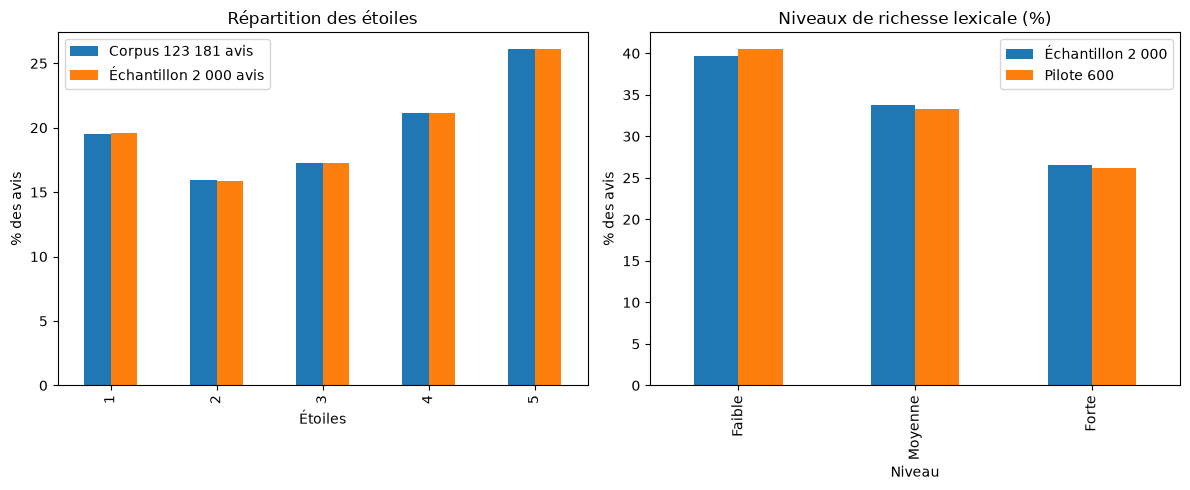

In [65]:
import matplotlib.pyplot as plt
import pandas as pd



# Répartition des étoiles

repartition_etoiles = pd.DataFrame({
    "Corpus 123 181 avis": df_nlp["stars"].value_counts(normalize=True).sort_index() * 100,
    "Échantillon 2 000 avis": df_2000["stars"].value_counts(normalize=True).sort_index() * 100})



# Richesse lexicale

repartition_richesse = pd.DataFrame({
    "Échantillon 2 000": df_2000["niveau_richesse"].value_counts(normalize=True).reindex(
        ["Faible", "Moyenne", "Forte"]) * 100,
    "Pilote 600": df_pilote_600["niveau_richesse"].value_counts(normalize=True).reindex(
        ["Faible", "Moyenne", "Forte"]) * 100})


# Graphiques

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


repartition_etoiles.plot(kind="bar", ax=axes[0])

axes[0].set_title("Répartition des étoiles")
axes[0].set_xlabel("Étoiles")
axes[0].set_ylabel("% des avis")
axes[0].legend()


repartition_richesse.plot(kind="bar", ax=axes[1])

axes[1].set_title("Niveaux de richesse lexicale (%)")
axes[1].set_xlabel("Niveau")
axes[1].set_ylabel("% des avis")
axes[1].legend()


plt.tight_layout()
plt.show()

### Validation du corpus pilote

Le corpus pilote contient 600 avis, tandis que les 1 400 avis restants sont
conservés pour la suite du projet.

La comparaison avec l'échantillon de 2 000 avis montre que la répartition des
étoiles est très proche, avec des écarts inférieurs à 0,3 point de pourcentage.

La distribution des niveaux de richesse lexicale est également conservée.
Les avis avec un score de richesse nul représentent 16,7 % du corpus pilote,
une proportion très proche de celle observée dans les 2 000 avis.

Enfin, les principales statistiques de longueur des avis restent similaires.

Le corpus pilote conserve donc une configuration proche de celle de
l'échantillon initial, avec des avis courts et longs, des niveaux de richesse
différents, ainsi que des formulations avec ou sans termes identifiés par le
lexique.

In [112]:
# export csv et xlsx

###df_2000.to_csv("../data/df_2000.csv",index=False,encoding="utf-8-sig")
###df_pilote_600.to_csv("../data/df_pilote_600.csv",index=False,encoding="utf-8-sig")
###df_reste_1400.to_csv("../data/df_reste_1400.csv",index=False,encoding="utf-8-sig")


#df_nlp.to_csv("df_nlp.csv", index=False)
#!pip install openpyxl
#df_nlp.to_excel("df_nlp.xlsx", index=False)

In [57]:


###df_reste_1400.to_excel("df_reste_1400.xlsx", index=False)


## Construction de l'antologie

**600 avis pilotes**
- lecture des avis
- identifier librement les aspects exprimés
- regrouper les formulations proches
- créer des catégories d'aspects
- tester ces catégories sur d'autres avis
- fusionner / séparer / ajouter si nécessaire
- ONTOLOGIE STABILISÉE
  
ex : "parcel arrived late" / "delivery took forever" / "received it the next day" / "shipping was incredibly quick" --> DELIVERY

"support didn't answer" / "staff were incredibly helpful" / "couldn't get hold of anyone" / "agent solved my issue" --> CUSTOMER_SERVICE

## 7. Construction progressive de l'ontologie des aspects

Le corpus pilote de 600 avis est utilisé pour identifier progressivement les
aspects réellement exprimés dans les commentaires.

L'objectif est de ne pas imposer dès le départ une liste définitive d'aspects.
Les avis sont analysés par lots afin d'identifier les thèmes récurrents,
regrouper les formulations proches et faire évoluer progressivement
l'ontologie.

Pour chaque aspect identifié, le sentiment exprimé dans l'avis est également
relevé.


**Les règles importantes d’annotation :**


Un aspect = un sujet réellement exprimé dans l’avis.


Plusieurs aspects dans le même avis → plusieurs couples aspect / sentiment.


Plusieurs mentions du même aspect → on ne le répète pas inutilement.


Un avis sans aspect clairement identifiable → laisses la ligne vide et écrire aucun aspect clair dans commentaire.


Si on ne devines pas ; on note l'hésitation dans commentaire.


stars n’est pas visible pendant l’annotation, comme décidé.


Le lexique précédent peut servir à comprendre le corpus, mais pas à imposer les réponses.


Avis 1 à 50 → annotation libre → liste de tous les aspects trouvés → regroupement des synonymes → Ontologie V0 


In [59]:
df_gold = pd.read_excel("../data/annotation_pilote_600_sapects_sentiments_gold_stable_final.xlsx")
print("Nombre d'annotations :", len(df_gold))
print("Nombre d'avis :", df_gold["review_id"].nunique())
print("Nombre d'aspects :", df_gold["aspect"].nunique())
doublons = df_gold.duplicated(subset=["review_id", "aspect", "sentiment"]).sum()
print("Doublons exacts :", doublons)

conflits = (df_gold.groupby(["review_id", "aspect"])["sentiment"].nunique())
conflits = conflits[conflits > 1]
print("Nombre de conflits restants :", len(conflits))
display(conflits)

Nombre d'annotations : 2271
Nombre d'avis : 600
Nombre d'aspects : 20
Doublons exacts : 0
Nombre de conflits restants : 0


Series([], Name: sentiment, dtype: int64)